# Convergence Simulation — UCB vs Random Search from Cold Start

Monte Carlo simulation comparing UCB acquisition against random baseline from a cold start (zero historical runs).
Uses an accuracy-oriented Random Forest oracle (trained on all 3,400 yelp2018 MF runs) as simulated ground truth.

**Question:** From a cold start on a 20K-cell categorical space with ~5 dimensions, how many UCB-guided runs to reach ESM 99% vs. random search?

In [118]:
import os
import itertools
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import FunctionTransformer
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.pipeline import Pipeline

from src.visualization import set_themes
from src.utils import get_kernel_id
from src.utils.config import parse_score_metric, Log10Transformer, Log2Transformer, model_based_parse_parameters, parse_parameters
from src.utils.styled_tables import data_preview_styled
from IPython.display import Markdown

from typing import List, Dict, Tuple, Optional
import io
import contextlib
from tqdm import tqdm

set_themes()
pl.Config.set_tbl_rows(20)

print("Current kernel:", get_kernel_id())

Current kernel: f0de51e5-1d5d-48ce-bdbf-5da16e07aca2


## Configuration

Define the target metric and the discrete hyperparameter space to enumerate over.

In [3]:
run_summary_file = "wandb/summary.parquet"

target_spec = "epoch/test_recall@20"
parsed_target = parse_score_metric(target_spec)
target_metric = "target"

feature_names = [
    "embedding_dimension",
    "shuffle",
    "l1_regularization",
    "l2_regularization",
    "embedding_dropout_rate",
]

## Data Loading

Load completed runs from the local parquet cache produced by `wandb/sync.py`.

In [4]:
experiment_runs = pl.read_parquet(run_summary_file)
experiment_runs = experiment_runs.filter(pl.col("model") == "matrix_factorization")

score_expression = sum(pl.col(m) * w for m, w in parsed_target.items())
experiment_runs = experiment_runs.with_columns(
    score_expression.list.max().alias(target_metric)
)

parameter_space = {}
for col in feature_names:
    unique_vals = sorted(experiment_runs[col].drop_nulls().unique().to_list())
    if col == "shuffle":
        unique_vals = [bool(v) for v in unique_vals]
    parameter_space[col] = unique_vals

total_space_size = 1
for values in parameter_space.values():
    total_space_size *= len(values)

print(f"Loaded {len(experiment_runs):,} runs")
print(f"Total joint parameter space: {total_space_size:,} configurations")
for col, vals in parameter_space.items():
    print(f"  {col}: {vals}")

Loaded 3,410 runs
Total joint parameter space: 20,000 configurations
  embedding_dimension: [2, 4, 8, 16, 32, 64, 128, 256, 512, 1024]
  shuffle: [False, True]
  l1_regularization: [0.0, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01]
  l2_regularization: [0.0, 1e-10, 1e-09, 1e-08, 1e-07, 1e-06, 1e-05, 0.0001, 0.001, 0.01]
  embedding_dropout_rate: [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]


## Data Preparation

In [5]:
required_cols = feature_names + [target_metric]
full_dataframe = experiment_runs.select(required_cols).drop_nulls()

full_dataframe = full_dataframe.with_columns(pl.col("shuffle").cast(pl.Boolean))

full_features = full_dataframe.select(feature_names)
full_target = full_dataframe[target_metric].to_numpy()

print(f"Training samples: {len(full_target):,}")
print(f"Target range:  [{full_target.min():.4f}, {full_target.max():.4f}]")
print(f"Target mean:   {full_target.mean():.4f}  ±  {full_target.std():.4f}")

Training samples: 3,410
Target range:  [0.0004, 0.0511]
Target mean:   0.0217  ±  0.0193


## Full Parameter Grid

Build the complete 20,000-cell grid and tag cells as explored or unexplored based on the 3,410 completed runs.

In [6]:
all_combinations = list(itertools.product(*parameter_space.values()))
full_grid = pl.DataFrame(
    {col: [row[i] for row in all_combinations] for i, col in enumerate(feature_names)}
)
full_grid = full_grid.with_columns(pl.col("shuffle").cast(pl.Boolean))

explored_dataframe = (
    full_dataframe
    .group_by(feature_names)
    .agg(pl.col(target_metric).mean().alias(f"observed_{target_metric}"))
)
explored_keys = set(
    tuple(row) for row in explored_dataframe.select(feature_names).to_numpy().tolist()
)
full_grid = full_grid.with_columns(
    pl.struct(feature_names)
    .map_elements(lambda s: tuple(s[c] for c in feature_names) in explored_keys, return_dtype=pl.Boolean)
    .alias("explored")
)
full_grid = full_grid.join(explored_dataframe, on=feature_names, how="left")

n_explored = full_grid["explored"].sum()
n_unexplored = len(full_grid) - n_explored
coverage_pct = 100 * n_explored / len(full_grid)

print(f"Total cells:  {len(full_grid):,}")
print(f"Explored:     {n_explored:,}  ({coverage_pct:.2f}%)")
print(f"Unexplored:   {n_unexplored:,}")

Total cells:  20,000
Explored:     1,516  (7.58%)
Unexplored:   18,484


## Oracle Model Training

Retrain the oracle with finalized hyperparams from notebook 2. This provides simulated ground truth — the oracle predicts the "true" test_recall@20 for any config.

**Final hyperparams:** `max_features=None`, `max_samples=None`, `min_samples_leaf=3`, `n_estimators=1024`

In [7]:
preprocessor = ColumnTransformer(
    transformers=[
        ("shuffle", FunctionTransformer(validate=True, feature_names_out="one-to-one"), ["shuffle"]),
        ("log2", Log2Transformer(inline_replace=False), ["embedding_dimension"]),
        ("log10", Log10Transformer(inline_replace=True), ["l1_regularization", "l2_regularization"]),
    ],
    remainder="passthrough",
    verbose_feature_names_out=False
)

oracle = Pipeline([
    ("preprocess", preprocessor),
    ("random_forest", RandomForestRegressor(
        n_estimators=1024,
        max_features=None,
        max_samples=None,
        min_samples_leaf=3,
        oob_score=True,
        n_jobs=-1,
        random_state=42,
    )),
])

sklearn.set_config(transform_output="pandas")
oracle.fit(full_features, full_target)
print(f"OOB R²: {oracle.named_steps['random_forest'].oob_score_:.4f}")


OOB R²: 0.9989


## Global Best Score

Compute the oracle's prediction across the full 20,000-cell grid to determine the true global optimum. This is used as the denominator for regret calculations in the simulation.

In [8]:
grid_features = full_grid.select(feature_names)
grid_predictions = oracle.predict(grid_features.to_pandas())

best_idx = grid_predictions.argmax()
best_score = grid_predictions[best_idx]
best_config = full_grid.row(best_idx)
best_config_tuple = tuple(best_config[full_grid.columns.index(c)] for c in feature_names)
already_explored = best_config_tuple in explored_keys

print(f"Global optimum oracle score: {best_score:.6f}")
print(f"Best config (index {best_idx}):")
for col in feature_names:
    print(f"  {col}: {best_config[full_grid.columns.index(col)]}")
print(f"  Explored: {'YES' if already_explored else 'NO'}")
print()
print(f"Total grid cells scored: {len(grid_predictions):,}")

Global optimum oracle score: 0.050729
Best config (index 16440):
  embedding_dimension: 512
  shuffle: False
  l1_regularization: 1e-07
  l2_regularization: 1e-07
  embedding_dropout_rate: 0.0
  Explored: YES

Total grid cells scored: 20,000


## Shared Experiment Functions

Define reusable runner and plotting functions. Each experiment below only needs to define `CONFIGS` and call these functions.

In [109]:
from concurrent.futures import ProcessPoolExecutor, as_completed
from multiprocessing import get_context

from src.utils.simulation_worker import run_trajectory

MAX_WORKERS = 16
output_directory = "wandb/trajectories"
probe_interval = 10

# Construct parameters_config for model_based_parse_parameters
parameters_config = {
    "model": {"value": "matrix_factorization"},
}
for col in feature_names:
    parameters_config[col] = {
        "distribution": "categorical",
        "values": parameter_space[col],
    }


def run_experiment(configs: List[Dict], n_runs: int = 1000, n_trajectories: int = 3):
    all_futures = []

    with ProcessPoolExecutor(max_workers=MAX_WORKERS, mp_context=get_context("spawn")) as executor:
        for config in configs:
            for seed in range(n_trajectories):
                all_futures.append(executor.submit(
                    run_trajectory,
                    strategy=config["strategy"],
                    seed=seed,
                    parameters_config=parameters_config,
                    oracle_pipeline=oracle,
                    feature_names=feature_names,
                    target_spec=target_spec,
                    global_best=best_score,
                    n_runs=n_runs,
                    beta=config.get("beta", 1.0),
                    estimator_count=config.get("estimator_count", 128),
                    virtual_sample_count=config.get("virtual_sample_count", 100),
                    virtual_lambda=config.get("virtual_lambda", 2.0),
                    max_samples=config.get("max_samples", 0.1),
                    min_samples_leaf=config.get("min_samples_leaf", 3),
                    probe_interval=probe_interval,
                    output_directory=output_directory,
                    label=config.get("label"),
                    verbose=True,
                ))

        all_history = [future.result() for future in as_completed(all_futures)]

    return pl.concat(all_history)


def filter_config(data: pl.DataFrame, config: Dict, group_keys: Tuple[str, ...]) -> pl.DataFrame:
    for key in group_keys:
        data = data.filter(pl.col(key) == config[key])
    return data


def plot_experiment(data: pl.DataFrame, configs: List[Dict], global_optimum: float, group_keys: Tuple[str, ...] = ("strategy", "max_samples")):
    from matplotlib.figure import Figure
    from matplotlib.axes import Axes

    fig: Figure
    axes: list[Axes]
    fig, axes = plt.subplots(4, 1, figsize=(10, 18))

    seeds = sorted(data["seed"].unique().to_list())
    n_runs_plot = data["run"].max() + 1

    aggregated = (
        data
        .group_by(["run"] + list(group_keys))
        .agg([
            pl.col("best_found").mean().alias("bf_mean"),
            pl.col("best_found").std(ddof=0).alias("bf_std"),
            pl.col("simple_regret").mean().alias("sr_mean"),
            pl.col("simple_regret").std(ddof=0).alias("sr_std"),
            pl.col("score").mean().alias("score_mean"),
            pl.col("score").std(ddof=0).alias("score_std"),
            pl.col("esm").drop_nulls().mean().alias("esm_mean"),
            pl.col("esm").drop_nulls().std(ddof=0).alias("esm_std"),
        ])
        .sort(["run"] + list(group_keys))
    )

    # Plot 1: Best found over runs
    ax: Axes = axes[0]
    for config in configs:
        agg = filter_config(aggregated, config, group_keys).sort("run")
        seed_trajs = filter_config(data, config, group_keys)
        for seed in seeds:
            traj = seed_trajs.filter(pl.col("seed") == seed).sort("run")
            ax.plot(traj["run"], traj["best_found"], color=config["color"], linewidth=0.5, alpha=0.2)
        ax.plot(agg["run"], agg["bf_mean"], label=config["label"], color=config["color"], linewidth=1.5)
        ax.fill_between(agg["run"], agg["bf_mean"] - agg["bf_std"], agg["bf_mean"] + agg["bf_std"],
                         color=config["color"], alpha=0.12)
    ax.axhline(global_optimum, color="green", linestyle="--", linewidth=1, alpha=0.7, label=f"Optimum ({global_optimum:.6f})")
    ax.set_xlabel("Run")
    ax.set_ylabel("Best found score")
    ax.set_title("Convergence (mean ± 1σ, per-seed in faded)")
    ax.legend(fontsize=9)
    ax.set_xlim(0, n_runs_plot - 1)

    # Plot 2: Simple regret over runs
    ax = axes[1]
    for config in configs:
        agg = filter_config(aggregated, config, group_keys).sort("run")
        seed_trajs = filter_config(data, config, group_keys)
        for seed in seeds:
            traj = seed_trajs.filter(pl.col("seed") == seed).sort("run")
            ax.plot(traj["run"], traj["simple_regret"], color=config["color"], linewidth=0.5, alpha=0.2)
        ax.plot(agg["run"], agg["sr_mean"], label=config["label"], color=config["color"], linewidth=1.5)
        ax.fill_between(agg["run"], agg["sr_mean"] - agg["sr_std"], agg["sr_mean"] + agg["sr_std"],
                         color=config["color"], alpha=0.12)
    ax.axhline(0, color="green", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_xlabel("Run")
    ax.set_ylabel("Simple regret")
    ax.set_title("Simple Regret (mean ± 1σ)")
    ax.legend(fontsize=9)
    ax.set_xlim(0, n_runs_plot - 1)

    # Plot 3: Per-run score with rolling mean
    ax = axes[2]
    score_window = 50
    for config in configs:
        agg = filter_config(aggregated, config, group_keys).sort("run")
        seed_trajs = filter_config(data, config, group_keys)
        for seed in seeds:
            traj = seed_trajs.filter(pl.col("seed") == seed).sort("run")
            rolling_seed = traj.select(
                pl.col("score").rolling_mean(window_size=score_window, min_samples=1)
            ).to_series().to_numpy()
            ax.plot(traj["run"], rolling_seed, color=config["color"], linewidth=0.5, alpha=0.2)
        rolling_mean = agg.select(
            pl.col("score_mean").rolling_mean(window_size=score_window, min_samples=1)
        ).to_series().to_numpy()
        rolling_std = agg.select(
            pl.col("score_std").rolling_mean(window_size=score_window, min_samples=1)
        ).to_series().to_numpy()
        ax.plot(agg["run"], rolling_mean, label=f"{config['label']} (MA{score_window})", color=config["color"], linewidth=1.5)
        ax.fill_between(agg["run"], rolling_mean - rolling_std, rolling_mean + rolling_std,
                         color=config["color"], alpha=0.12)
    ax.axhline(global_optimum, color="green", linestyle="--", linewidth=1, alpha=0.7)
    ax.set_xlabel("Run")
    ax.set_ylabel("Score (MA20)")
    ax.set_title(f"Per-Run Score (MA{score_window}, mean ± 1σ)")
    ax.legend(fontsize=9)
    ax.set_xlim(0, n_runs_plot - 1)

    # Plot 4: ESM over runs
    ax = axes[3]
    esm_window = 20
    for config in configs:
        seed_trajs = filter_config(data, config, group_keys)
        for seed in seeds:
            traj = seed_trajs.filter(pl.col("seed") == seed).sort("run")
            esm_data = traj.filter(pl.col("esm").is_not_null())
            if len(esm_data) > 0:
                rolling_esm_seed = esm_data.select(
                    pl.col("esm").rolling_mean(window_size=max(1, len(esm_data) // 10), min_samples=1)
                ).to_series().to_numpy()
                ax.plot(esm_data["run"], rolling_esm_seed, color=config["color"], linewidth=0.5, alpha=0.2)
        agg_esm = filter_config(aggregated, config, group_keys).filter(pl.col("esm_mean").is_not_null()).sort("run")
        if len(agg_esm) > 0:
            rolling_esm = agg_esm.select(
                pl.col("esm_mean").rolling_mean(window_size=esm_window, min_samples=1)
            ).to_series().to_numpy()
            rolling_esm_std = agg_esm.select(
                pl.col("esm_std").rolling_mean(window_size=esm_window, min_samples=1)
            ).to_series().to_numpy()
            ax.plot(agg_esm["run"], rolling_esm, label=config["label"], color=config["color"], linewidth=1.5)
            ax.fill_between(agg_esm["run"], rolling_esm - rolling_esm_std, rolling_esm + rolling_esm_std,
                             color=config["color"], alpha=0.12)
    ax.axhline(100, color="green", linestyle="--", linewidth=1, alpha=0.7, label="100% saturation")
    ax.set_xlabel("Run")
    ax.set_ylabel("ESM (%)")
    ax.set_title("Exploration Saturation (MA20, mean ± 1σ)")
    ax.legend(fontsize=9)
    ax.set_xlim(0, n_runs_plot - 1)
    ax.set_ylim(top=140)

    plt.tight_layout()
    plt.show()

## Experiment 1 — min_samples_leaf sweep

Comparing `min_samples_leaf ∈ {1, 2, 3, 5, 10}` for UCB acquisition. Random baseline at leaf=3. All with `max_samples=0.1`, `virtual_lambda=1.0`, β=1.0.

In [ ]:
CONFIGS = [
    {"strategy": "random", "min_samples_leaf": 3,  "max_samples": 0.1, "virtual_lambda": 1.0, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 100, "label": "Random",        "color": "#ca6702"},
    {"strategy": "ucb",    "min_samples_leaf": 1,  "max_samples": 0.1, "virtual_lambda": 1.0, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 100, "label": "UCB (leaf=1)",  "color": "#d62828"},
    {"strategy": "ucb",    "min_samples_leaf": 2,  "max_samples": 0.1, "virtual_lambda": 1.0, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 100, "label": "UCB (leaf=2)",  "color": "#f77f00"},
    {"strategy": "ucb",    "min_samples_leaf": 3,  "max_samples": 0.1, "virtual_lambda": 1.0, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 100, "label": "UCB (leaf=3)",  "color": "#2e86ab"},
    {"strategy": "ucb",    "min_samples_leaf": 5,  "max_samples": 0.1, "virtual_lambda": 1.0, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 100, "label": "UCB (leaf=5)",  "color": "#2d6a4f"},
    {"strategy": "ucb",    "min_samples_leaf": 10, "max_samples": 0.1, "virtual_lambda": 1.0, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 100, "label": "UCB (leaf=10)", "color": "#7209b7"},
]
N_TRAJECTORIES = 3
N_RUNS = 2000

n_total_runs = len(CONFIGS) * N_TRAJECTORIES * N_RUNS
print(f"Configs: {len(CONFIGS)} \u00d7 {N_TRAJECTORIES} seeds \u00d7 {N_RUNS} runs = {n_total_runs:,} total")

leaf_experiment_results: pl.DataFrame = run_experiment(CONFIGS, n_runs=N_RUNS, n_trajectories=N_TRAJECTORIES)

Configs: 6 × 3 seeds × 2000 runs = 36,000 total


Total records : 36,000
Seeds        : [0, 1, 2]
Leaf values  : [1, 2, 3, 5, 10]

shape: (18, 7)
┌──────────┬──────────────────┬──────┬──────┬──────────────┬──────────┬──────────┐
│ strategy ┆ min_samples_leaf ┆ seed ┆ runs ┆ final_regret ┆ best     ┆ esm      │
│ ---      ┆ ---              ┆ ---  ┆ ---  ┆ ---          ┆ ---      ┆ ---      │
│ str      ┆ i64              ┆ i64  ┆ i64  ┆ f64          ┆ f64      ┆ f64      │
╞══════════╪══════════════════╪══════╪══════╪══════════════╪══════════╪══════════╡
│ random   ┆ 3                ┆ 0    ┆ 1999 ┆ 0.0          ┆ 0.050729 ┆ 97.7221  │
│ random   ┆ 3                ┆ 1    ┆ 1999 ┆ 0.00043      ┆ 0.050299 ┆ 98.3892  │
│ random   ┆ 3                ┆ 2    ┆ 1999 ┆ 0.00043      ┆ 0.050299 ┆ 97.8599  │
│ ucb      ┆ 1                ┆ 0    ┆ 1999 ┆ 0.0          ┆ 0.050729 ┆ 92.0823  │
│ ucb      ┆ 1                ┆ 1    ┆ 1999 ┆ 0.0          ┆ 0.050729 ┆ 90.9865  │
│ ucb      ┆ 1                ┆ 2    ┆ 1999 ┆ 0.0          ┆ 0.050729 ┆ 89

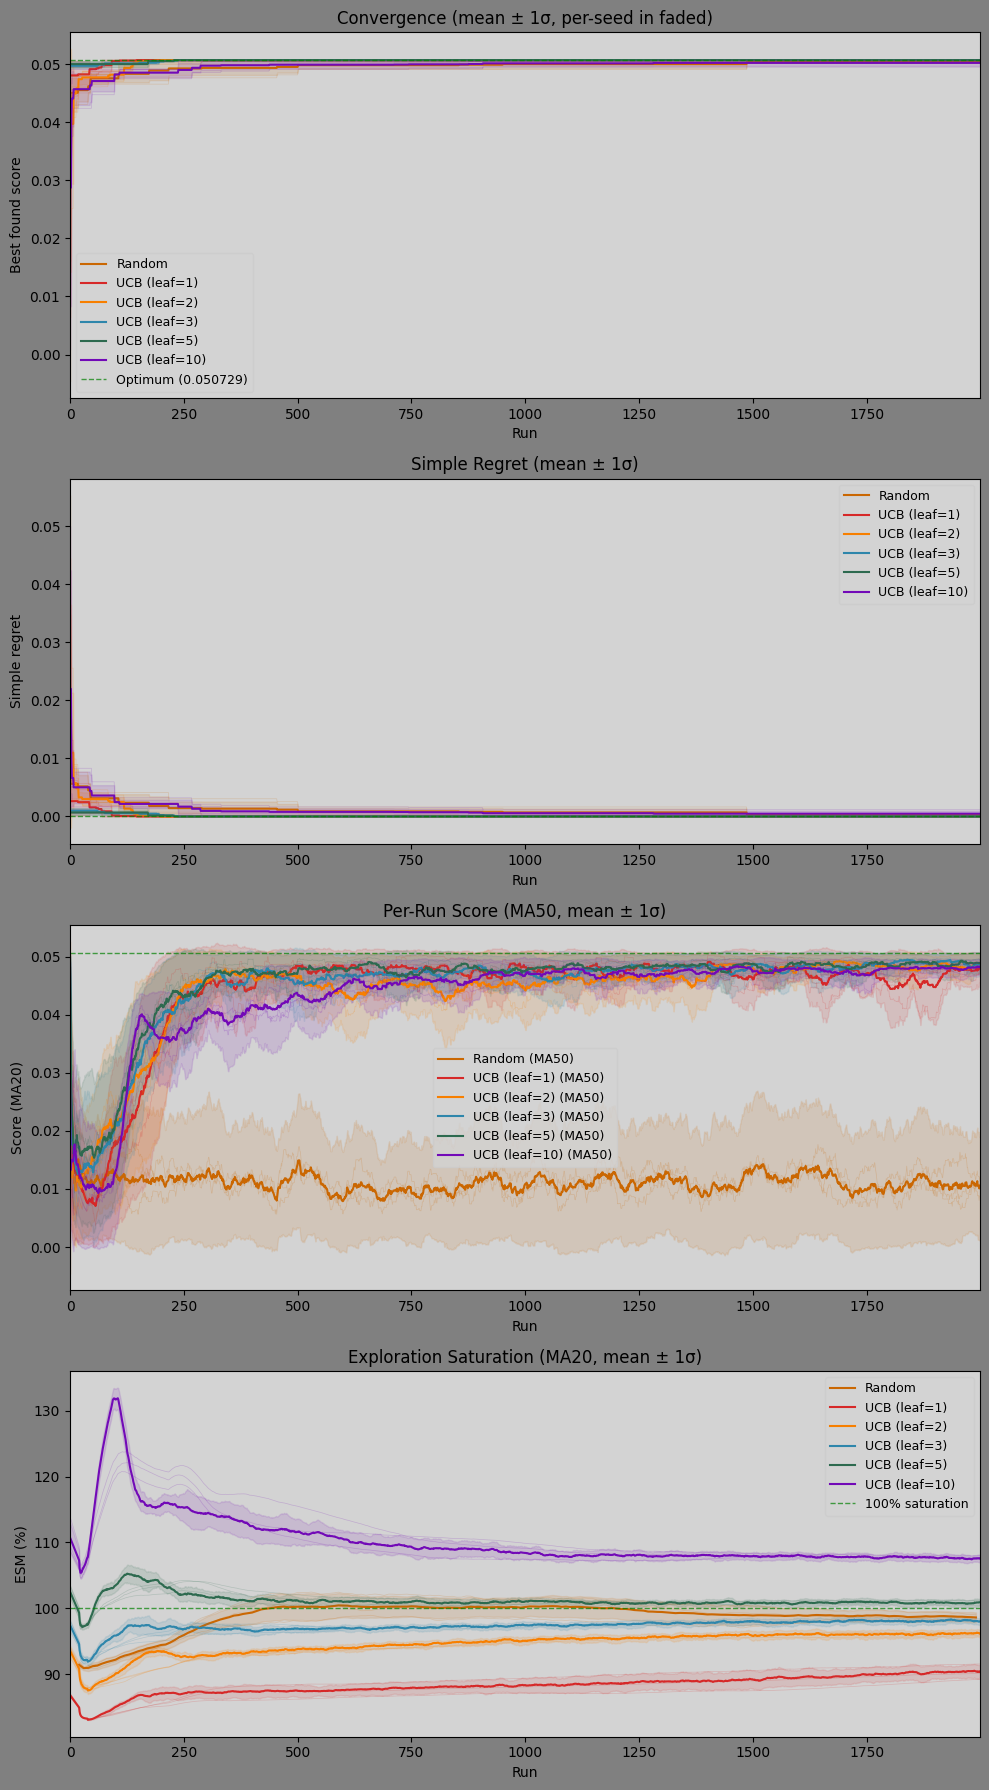

In [49]:
n_total = len(leaf_experiment_results)
print(f"Total records : {n_total:,}")
print(f"Seeds        : {sorted(leaf_experiment_results['seed'].unique().to_list())}")
print(f"Leaf values  : {sorted(leaf_experiment_results['min_samples_leaf'].unique().to_list())}")
print()

# Focus on the first N runs
focus_region_result = leaf_experiment_results.filter(pl.col("run") <= 2000)

summary = (
    focus_region_result
    .group_by(["strategy", "min_samples_leaf", "seed"])
    .agg([
        pl.col("run").max().alias("runs"),
        pl.col("simple_regret").last().alias("final_regret"),
        pl.col("best_found").last().alias("best"),
        pl.col("esm").drop_nulls().last().alias("esm"),
    ])
    .sort(["strategy", "min_samples_leaf", "seed"])
)
print(summary)

plot_experiment(focus_region_result, CONFIGS, best_score, group_keys=("strategy", "min_samples_leaf"))

### Last Mile Convergence Analysis
esm from the last 500 runs, showing what values of esm are reached in the final phase of the experiment.

In [53]:
leaf_experiment_results.filter(
    pl.col("strategy") == "ucb",
    pl.col("run") >= pl.col("run").max() - 200,
    pl.col("run") < pl.col("run").max() - 0
).group_by(["strategy", "min_samples_leaf"]).agg(
    pl.col("run").min().alias("min_run"),
    pl.col("run").max().alias("max_run"),
    pl.col("esm").mean().alias("esm_mean"),
    pl.col("esm").std().alias("esm_std")
).sort("min_samples_leaf")

strategy,min_samples_leaf,min_run,max_run,esm_mean,esm_std
str,i64,i64,i64,f64,f64
"""ucb""",1,1799,1998,90.289666,1.169176
"""ucb""",2,1799,1998,96.123758,0.840384
"""ucb""",3,1799,1998,98.088956,0.67704
"""ucb""",5,1799,1998,100.836263,0.667172
"""ucb""",10,1799,1998,107.68878,0.776302


### First Convergence Analysis (MA20)

Smooths ESM with a 20-run moving average per trajectory to assess saturation stability across different `min_samples_leaf` values.

In [ ]:
leaf_experiment_results.filter(
    pl.col("strategy") == "ucb",
).with_columns(
    pl.col("esm")
    .rolling_mean(window_size=20, min_samples=1)
    .over(["strategy", "min_samples_leaf", "seed"])
    .alias("esm_ma20")
).group_by(["strategy", "min_samples_leaf", "seed"]).agg(
    esm95_count = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 95).count(),
    esm95_ratio = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 95).count() / pl.col("esm_ma20").count(),
    esm95_first = pl.col("run").filter(pl.col("esm_ma20") >= 95).min().alias("first_esm_95"),
    esm99_count = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 99).count(),
    esm99_ratio = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 99).count() / pl.col("esm_ma20").count(),
    esm99_first = pl.col("run").filter(pl.col("esm_ma20") >= 99).min().alias("first_esm_99"),
    esm100_count = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 100).count(),
    esm100_ratio = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 100).count() / pl.col("esm_ma20").count(),
    esm100_first = pl.col("run").filter(pl.col("esm_ma20") >= 100).min().alias("first_esm_100"),
).group_by(["strategy", "min_samples_leaf"]).agg(
    esm95_count = pl.col("esm95_count").mean(),
    esm95_ratio = pl.col("esm95_ratio").mean(),
    esm95_first = pl.col("esm95_first").mean(),
    esm99_count = pl.col("esm99_count").mean(),
    esm99_ratio = pl.col("esm99_ratio").mean(),
    esm99_first = pl.col("esm99_first").mean(),
    esm100_count = pl.col("esm100_count").mean(),
    esm100_ratio = pl.col("esm100_ratio").mean(),
    esm100_first = pl.col("esm100_first").mean(),
).sort("min_samples_leaf")

strategy,min_samples_leaf,esm95_count,esm95_ratio,esm95_first,esm99_count,esm99_ratio,esm99_first,esm100_count,esm100_ratio,esm100_first
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ucb""",1,0.0,0.0,null,0.0,0.0,null,0.0,0.0,null
"""ucb""",2,1068.0,0.534,856.0,0.0,0.0,null,0.0,0.0,null
"""ucb""",3,1936.333333,0.968167,0.0,0.0,0.0,null,0.0,0.0,null
"""ucb""",5,2000.0,1.0,0.0,1971.666667,0.985833,0.0,1966.333333,0.983167,0.0
"""ucb""",10,2000.0,1.0,0.0,2000.0,1.0,0.0,2000.0,1.0,0.0


## Experiment 2 — beta sweep

Comparing `β ∈ {0.5, 1.0, 2.0, 4.0}` for UCB acquisition. Random baseline at β=1.0. All with `max_samples=0.1`, `virtual_lambda=1.0`, `min_samples_leaf=3`.

In [ ]:
CONFIGS = [
    {"strategy": "random", "beta": 1.0, "max_samples": 0.1, "virtual_lambda": 1.0, "min_samples_leaf": 3, "estimator_count": 128, "virtual_sample_count": 100, "label": "Random",            "color": "#ca6702"},
    {"strategy": "ucb",    "beta": 0.5, "max_samples": 0.1, "virtual_lambda": 1.0, "min_samples_leaf": 3, "estimator_count": 128, "virtual_sample_count": 100, "label": "UCB (\u03b2=0.5)",  "color": "#d62828"},
    {"strategy": "ucb",    "beta": 1.0, "max_samples": 0.1, "virtual_lambda": 1.0, "min_samples_leaf": 3, "estimator_count": 128, "virtual_sample_count": 100, "label": "UCB (\u03b2=1.0)",  "color": "#f77f00"},
    {"strategy": "ucb",    "beta": 2.0, "max_samples": 0.1, "virtual_lambda": 1.0, "min_samples_leaf": 3, "estimator_count": 128, "virtual_sample_count": 100, "label": "UCB (\u03b2=2.0)",  "color": "#2e86ab"},
    {"strategy": "ucb",    "beta": 4.0, "max_samples": 0.1, "virtual_lambda": 1.0, "min_samples_leaf": 3, "estimator_count": 128, "virtual_sample_count": 100, "label": "UCB (\u03b2=4.0)",  "color": "#2d6a4f"},
]
N_TRAJECTORIES = 3
N_RUNS = 2000

n_total_runs = len(CONFIGS) * N_TRAJECTORIES * N_RUNS
print(f"Configs: {len(CONFIGS)} \u00d7 {N_TRAJECTORIES} seeds \u00d7 {N_RUNS} runs = {n_total_runs:,} total")

beta_experiment_results: pl.DataFrame = run_experiment(CONFIGS, n_runs=N_RUNS, n_trajectories=N_TRAJECTORIES)

Configs: 5 × 3 seeds × 2000 runs = 30,000 total


Total records : 30,000
Seeds        : [0, 1, 2]
Beta values  : [0.5, 1.0, 2.0, 4.0]

shape: (15, 7)
┌──────────┬──────┬──────┬──────┬──────────────┬──────────┬──────────┐
│ strategy ┆ beta ┆ seed ┆ runs ┆ final_regret ┆ best     ┆ esm      │
│ ---      ┆ ---  ┆ ---  ┆ ---  ┆ ---          ┆ ---      ┆ ---      │
│ str      ┆ f64  ┆ i64  ┆ i64  ┆ f64          ┆ f64      ┆ f64      │
╞══════════╪══════╪══════╪══════╪══════════════╪══════════╪══════════╡
│ random   ┆ 1.0  ┆ 0    ┆ 1999 ┆ 0.000233     ┆ 0.050496 ┆ 98.4946  │
│ random   ┆ 1.0  ┆ 1    ┆ 1999 ┆ 0.000233     ┆ 0.050496 ┆ 98.0463  │
│ random   ┆ 1.0  ┆ 2    ┆ 1999 ┆ 0.000233     ┆ 0.050496 ┆ 98.6534  │
│ ucb      ┆ 0.5  ┆ 0    ┆ 1999 ┆ 0.0          ┆ 0.050729 ┆ 104.0758 │
│ ucb      ┆ 0.5  ┆ 1    ┆ 1999 ┆ 0.0          ┆ 0.050729 ┆ 102.8187 │
│ ucb      ┆ 0.5  ┆ 2    ┆ 1999 ┆ 0.0          ┆ 0.050729 ┆ 103.094  │
│ ucb      ┆ 1.0  ┆ 0    ┆ 1999 ┆ 0.0          ┆ 0.050729 ┆ 97.7193  │
│ ucb      ┆ 1.0  ┆ 1    ┆ 1999 ┆ 0.0          ┆

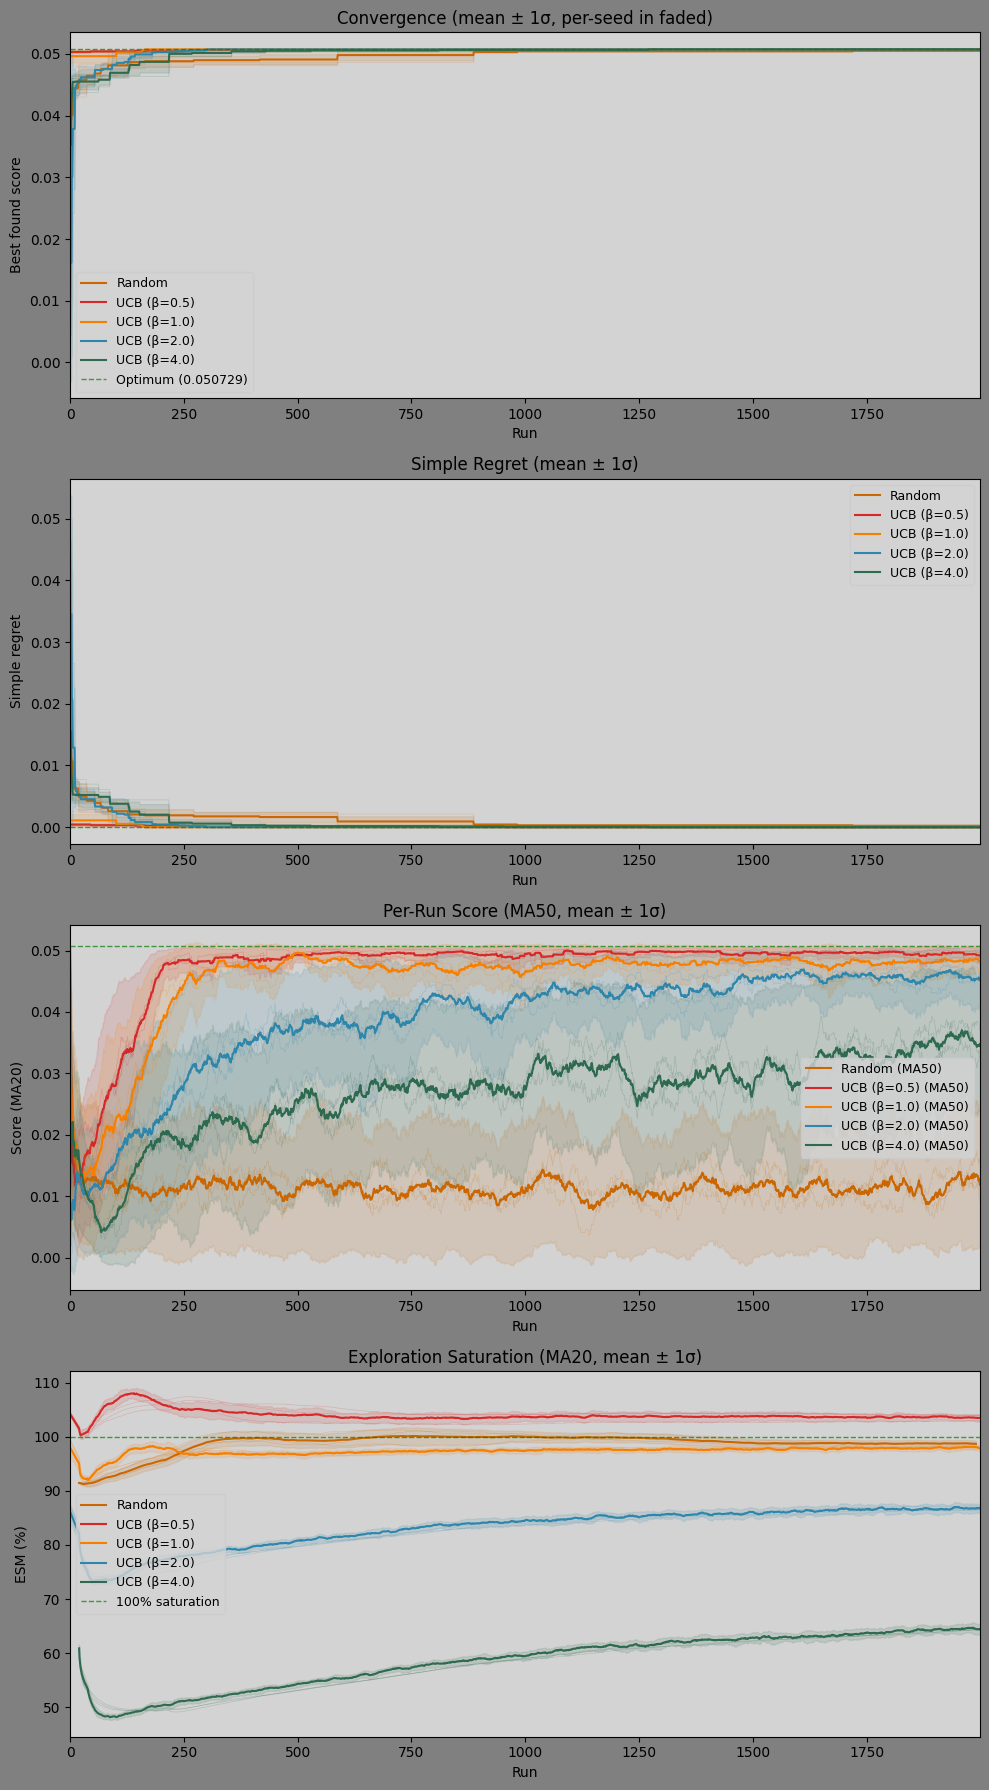

In [67]:
n_total = len(beta_experiment_results)
print(f"Total records : {n_total:,}")
print(f"Seeds        : {sorted(beta_experiment_results['seed'].unique().to_list())}")
print(f"Beta values  : {sorted(beta_experiment_results['beta'].unique().to_list())}")
print()

# Focus on the first N runs
focus_region_result = beta_experiment_results.filter(pl.col("run") <= 2000)

summary = (
    focus_region_result
    .group_by(["strategy", "beta", "seed"])
    .agg([
        pl.col("run").max().alias("runs"),
        pl.col("simple_regret").last().alias("final_regret"),
        pl.col("best_found").last().alias("best"),
        pl.col("esm").drop_nulls().last().alias("esm"),
    ])
    .sort(["strategy", "beta", "seed"])
)
print(summary)

plot_experiment(focus_region_result, CONFIGS, best_score, group_keys=("strategy", "beta"))

### Last Mile Convergence Analysis
esm from the last 500 runs, showing what values of esm are reached in the final phase of the experiment.

In [94]:
beta_experiment_results.filter(
    pl.col("strategy") == "ucb",
    pl.col("run") >= pl.col("run").max() - 200,
    pl.col("run") < pl.col("run").max() - 0
).group_by(["strategy", "beta"]).agg(
    pl.col("run").min().alias("min_run"),
    pl.col("run").max().alias("max_run"),
    pl.col("esm").mean().alias("esm_mean"),
    pl.col("esm").std().alias("esm_std")
).sort("beta")

strategy,beta,min_run,max_run,esm_mean,esm_std
str,f64,i64,i64,f64,f64
"""ucb""",0.5,1799,1998,103.618057,0.739819
"""ucb""",1.0,1799,1998,97.93442,0.693783
"""ucb""",2.0,1799,1998,86.673877,1.141692
"""ucb""",4.0,1799,1998,64.341056,1.171058


### First Convergence Analysis (MA20)

Smooths ESM with a 20-run moving average per trajectory to assess saturation stability across different UCB exploration weights β.

In [70]:
beta_experiment_results.filter(
    pl.col("strategy") == "ucb",
).with_columns(
    pl.col("esm")
    .rolling_mean(window_size=20, min_samples=1)
    .over(["strategy", "beta", "seed"])
    .alias("esm_ma20")
).group_by(["strategy", "beta", "seed"]).agg(
    esm95_count = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 95).count(),
    esm95_ratio = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 95).count() / pl.col("esm_ma20").count(),
    esm95_first = pl.col("run").filter(pl.col("esm_ma20") >= 95).min().alias("first_esm_95"),
    esm99_count = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 99).count(),
    esm99_ratio = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 99).count() / pl.col("esm_ma20").count(),
    esm99_first = pl.col("run").filter(pl.col("esm_ma20") >= 99).min().alias("first_esm_99"),
    esm100_count = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 100).count(),
    esm100_ratio = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 100).count() / pl.col("esm_ma20").count(),
    esm100_first = pl.col("run").filter(pl.col("esm_ma20") >= 100).min().alias("first_esm_100"),
).group_by(["strategy", "beta"]).agg(
    esm95_count = pl.col("esm95_count").mean(),
    esm95_ratio = pl.col("esm95_ratio").mean(),
    esm95_first = pl.col("esm95_first").mean(),
    esm99_count = pl.col("esm99_count").mean(),
    esm99_ratio = pl.col("esm99_ratio").mean(),
    esm99_first = pl.col("esm99_first").mean(),
    esm100_count = pl.col("esm100_count").mean(),
    esm100_ratio = pl.col("esm100_ratio").mean(),
    esm100_first = pl.col("esm100_first").mean(),
).sort("beta")

strategy,beta,esm95_count,esm95_ratio,esm95_first,esm99_count,esm99_ratio,esm99_first,esm100_count,esm100_ratio,esm100_first
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ucb""",0.5,2000.0,1.0,0.0,1997.333333,0.998667,0.0,1990.0,0.995,0.0
"""ucb""",1.0,1932.666667,0.966333,0.0,8.0,0.004,91.5,0.0,0.0,null
"""ucb""",2.0,0.0,0.0,null,0.0,0.0,null,0.0,0.0,null
"""ucb""",4.0,0.0,0.0,null,0.0,0.0,null,0.0,0.0,null


## Experiment 3 — lambda sweep

Comparing `virtual_lambda ∈ {0.5, 1.0, 2.0}` for UCB acquisition. Random baseline at λ=1.0. All with `max_samples=0.1`, `min_samples_leaf=3`, β=1.0.

In [ ]:
CONFIGS = [
    {"strategy": "random", "virtual_lambda": 1.0, "max_samples": 0.1, "min_samples_leaf": 3, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 100, "label": "Random",          "color": "#ca6702"},
    {"strategy": "ucb",    "virtual_lambda": 0.5, "max_samples": 0.1, "min_samples_leaf": 3, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 100, "label": "UCB (\u03bb=0.5)",     "color": "#d62828"},
    {"strategy": "ucb",    "virtual_lambda": 1.0, "max_samples": 0.1, "min_samples_leaf": 3, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 100, "label": "UCB (\u03bb=1.0)",     "color": "#f77f00"},
    {"strategy": "ucb",    "virtual_lambda": 2.0, "max_samples": 0.1, "min_samples_leaf": 3, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 100, "label": "UCB (\u03bb=2.0)",     "color": "#2e86ab"},
]
N_TRAJECTORIES = 3
N_RUNS = 10000

n_total_runs = len(CONFIGS) * N_TRAJECTORIES * N_RUNS
print(f"Configs: {len(CONFIGS)} \u00d7 {N_TRAJECTORIES} seeds \u00d7 {N_RUNS} runs = {n_total_runs:,} total")

lambda_experiment_results: pl.DataFrame = run_experiment(CONFIGS, n_runs=N_RUNS, n_trajectories=N_TRAJECTORIES)

Configs: 4 × 3 seeds × 10000 runs = 120,000 total


Total records : 120,000
Seeds        : [0, 1, 2]
Lambda values: [0.5, 1.0, 2.0]

shape: (12, 7)
┌──────────┬────────────────┬──────┬──────┬──────────────┬──────────┬──────────┐
│ strategy ┆ virtual_lambda ┆ seed ┆ runs ┆ final_regret ┆ best     ┆ esm      │
│ ---      ┆ ---            ┆ ---  ┆ ---  ┆ ---          ┆ ---      ┆ ---      │
│ str      ┆ f64            ┆ i64  ┆ i64  ┆ f64          ┆ f64      ┆ f64      │
╞══════════╪════════════════╪══════╪══════╪══════════════╪══════════╪══════════╡
│ random   ┆ 1.0            ┆ 0    ┆ 2000 ┆ 0.000233     ┆ 0.050496 ┆ 99.8161  │
│ random   ┆ 1.0            ┆ 1    ┆ 2000 ┆ 0.0          ┆ 0.050729 ┆ 101.4508 │
│ random   ┆ 1.0            ┆ 2    ┆ 2000 ┆ 0.000585     ┆ 0.050144 ┆ 99.0538  │
│ ucb      ┆ 0.5            ┆ 0    ┆ 2000 ┆ 0.0          ┆ 0.050729 ┆ 97.6041  │
│ ucb      ┆ 0.5            ┆ 1    ┆ 2000 ┆ 0.0          ┆ 0.050729 ┆ 98.1599  │
│ ucb      ┆ 0.5            ┆ 2    ┆ 2000 ┆ 0.0          ┆ 0.050729 ┆ 98.8669  │
│ ucb      ┆ 

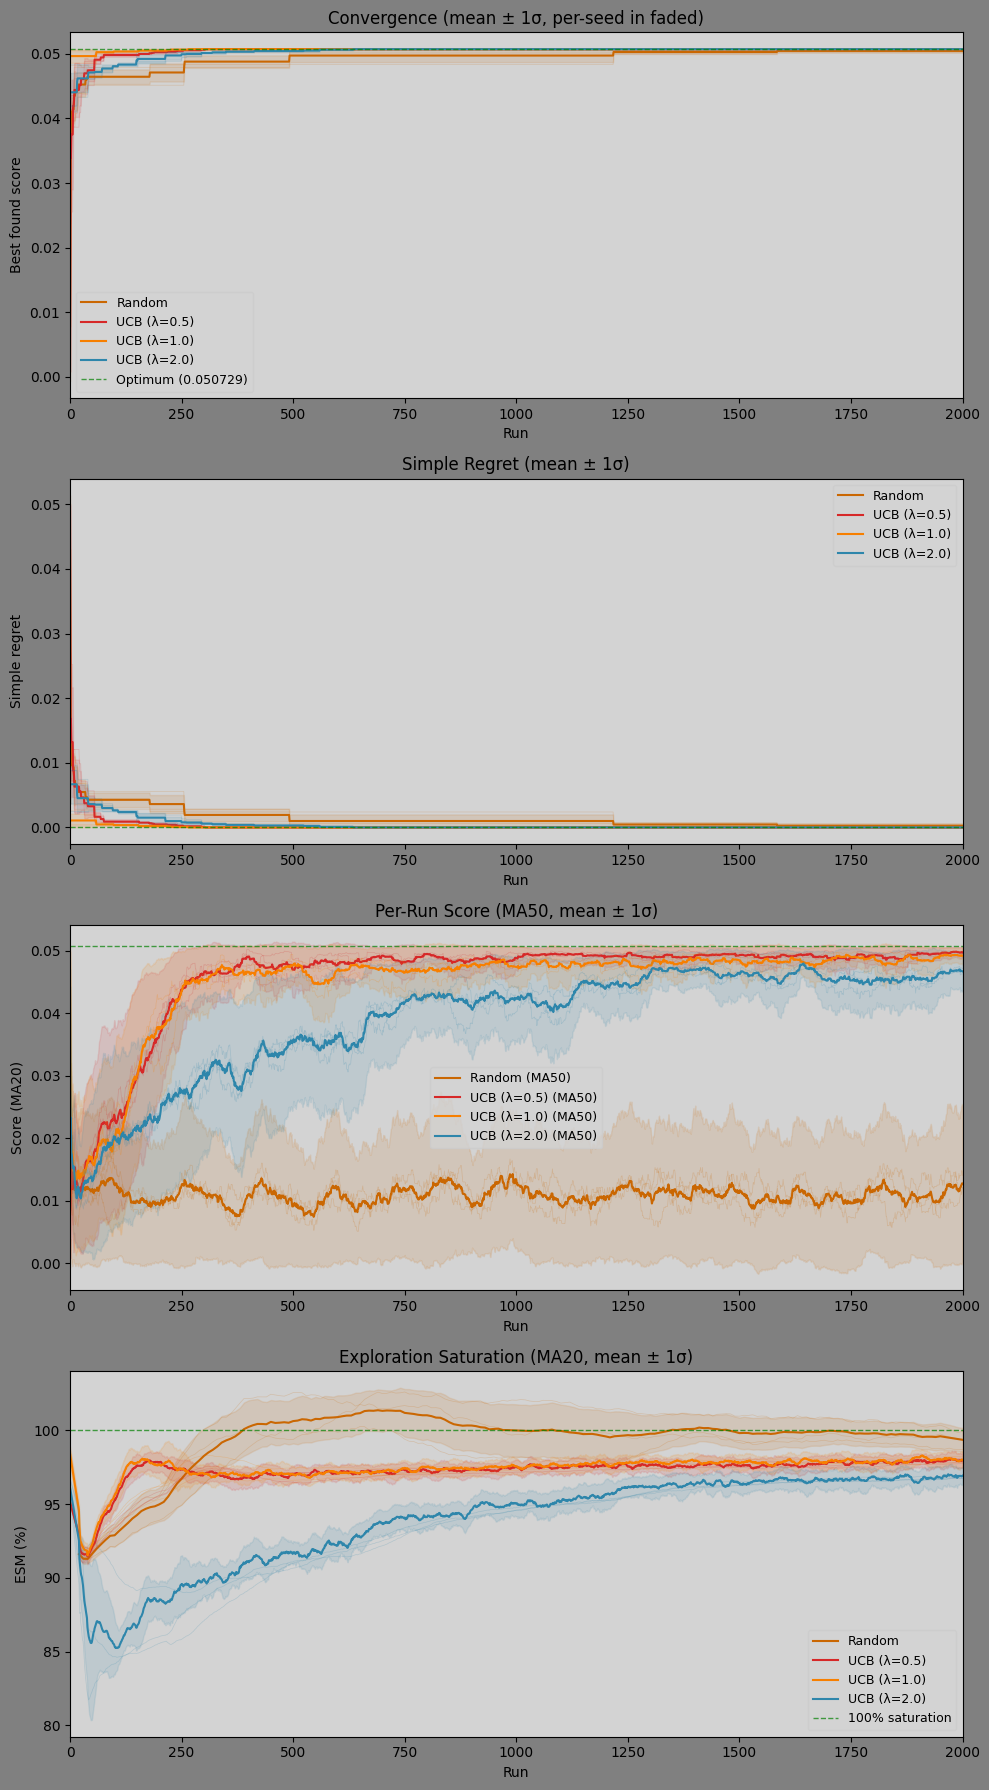

In [73]:
n_total = len(lambda_experiment_results)
print(f"Total records : {n_total:,}")
print(f"Seeds        : {sorted(lambda_experiment_results['seed'].unique().to_list())}")
print(f"Lambda values: {sorted(lambda_experiment_results['virtual_lambda'].unique().to_list())}")
print()

# Focus on the first N runs
focus_region_result = lambda_experiment_results.filter(pl.col("run") <= 2000)

summary = (
    focus_region_result
    .group_by(["strategy", "virtual_lambda", "seed"])
    .agg([
        pl.col("run").max().alias("runs"),
        pl.col("simple_regret").last().alias("final_regret"),
        pl.col("best_found").last().alias("best"),
        pl.col("esm").drop_nulls().last().alias("esm"),
    ])
    .sort(["strategy", "virtual_lambda", "seed"])
)
print(summary)

plot_experiment(focus_region_result, CONFIGS, best_score, group_keys=("strategy", "virtual_lambda"))

### Last Mile Convergence Analysis
esm from the last 500 runs, showing what values of esm are reached in the final phase of the experiment.

In [75]:
lambda_experiment_results.filter(
    pl.col("strategy") == "ucb",
    pl.col("run") >= pl.col("run").max() - 200,
    pl.col("run") < pl.col("run").max() - 0
).group_by(["strategy", "virtual_lambda"]).agg(
    pl.col("run").min().alias("min_run"),
    pl.col("run").max().alias("max_run"),
    pl.col("esm").mean().alias("esm_mean"),
    pl.col("esm").std().alias("esm_std")
).sort("virtual_lambda")

strategy,virtual_lambda,min_run,max_run,esm_mean,esm_std
str,f64,i64,i64,f64,f64
"""ucb""",0.5,9799,9998,98.623407,0.744136
"""ucb""",1.0,9799,9998,98.60453,0.760437
"""ucb""",2.0,9799,9998,98.518001,0.924815


### First Convergence Analysis (MA20)

Smooths ESM with a 20-run moving average per trajectory, then measures how much time is spent above 99% — a more robust view than raw per-run thresholds.

| λ | First run ESM ≥ 99% | Runs at ≥ 99% | % of total |
|---|-------------------|--------------|-----------|
| 0.5 | ~1,888 | 839 | 8.4% |
| 1.0 | ~5,314 | 515 | 5.1% |
| 2.0 | ~8,752 | 10 | 0.1% |

**Insight:** Even λ=0.5 (the best performer) only stays above 99% for ~8% of the trajectory. Most runs sit at ~98% ESM. This is because **ESM measures grid coverage, not search convergence** — `best_ucb ≈ best_observed / 0.98` means the surrogate honestly believes the best unexplored cell among ~19,360 remaining cells could be ~2% better than what's been found. That's a reasonable assessment given only ~3.2% of the 20K grid has been explored by UCB λ=0.5.

In [76]:
lambda_experiment_results.filter(
    pl.col("strategy") == "ucb",
).with_columns(
    pl.col("esm")
    .rolling_mean(window_size=20, min_samples=1)
    .over(["strategy", "virtual_lambda", "seed"])
    .alias("esm_ma20")
).group_by(["strategy", "virtual_lambda", "seed"]).agg(
    esm95_count = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 95).count(),
    esm95_ratio = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 95).count() / pl.col("esm_ma20").count(),
    esm95_first = pl.col("run").filter(pl.col("esm_ma20") >= 95).min().alias("first_esm_95"),
    esm99_count = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 99).count(),
    esm99_ratio = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 99).count() / pl.col("esm_ma20").count(),
    esm99_first = pl.col("run").filter(pl.col("esm_ma20") >= 99).min().alias("first_esm_99"),
    esm100_count = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 100).count(),
    esm100_ratio = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 100).count() / pl.col("esm_ma20").count(),
    esm100_first = pl.col("run").filter(pl.col("esm_ma20") >= 100).min().alias("first_esm_100"),
).group_by(["strategy", "virtual_lambda"]).agg(
    esm95_count = pl.col("esm95_count").mean(),
    esm95_ratio = pl.col("esm95_ratio").mean(),
    esm95_first = pl.col("esm95_first").mean(),
    esm99_count = pl.col("esm99_count").mean(),
    esm99_ratio = pl.col("esm99_ratio").mean(),
    esm99_first = pl.col("esm99_first").mean(),
    esm100_count = pl.col("esm100_count").mean(),
    esm100_ratio = pl.col("esm100_ratio").mean(),
    esm100_first = pl.col("esm100_first").mean(),
).sort("virtual_lambda")

strategy,virtual_lambda,esm95_count,esm95_ratio,esm95_first,esm99_count,esm99_ratio,esm99_first,esm100_count,esm100_ratio,esm100_first
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ucb""",0.5,9923.666667,0.992367,0.0,29.666667,0.002967,7299.333333,0.0,0.0,null
"""ucb""",1.0,9929.0,0.9929,0.0,68.0,0.0068,2068.333333,0.0,0.0,null
"""ucb""",2.0,9014.0,0.9014,0.0,12.666667,0.001267,9169.0,0.0,0.0,null


## Experiment 4 — max_samples sweep

Comparing `max_samples ∈ {0.1, 0.5, 1.0}` for UCB acquisition. Random baseline at ms=0.1. All with `virtual_lambda=1.0`, `min_samples_leaf=3`, β=1.0.

In [ ]:
CONFIGS = [
    {"strategy": "random", "max_samples": 0.1, "virtual_lambda": 1.0, "min_samples_leaf": 3, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 100, "label": "Random",              "color": "#ca6702"},
    {"strategy": "ucb",    "max_samples": 0.1, "virtual_lambda": 1.0, "min_samples_leaf": 3, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 100, "label": "UCB (ms=0.1)",        "color": "#d62828"},
    {"strategy": "ucb",    "max_samples": 0.5, "virtual_lambda": 1.0, "min_samples_leaf": 3, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 100, "label": "UCB (ms=0.5)",        "color": "#f77f00"},
    {"strategy": "ucb",    "max_samples": 1.0, "virtual_lambda": 1.0, "min_samples_leaf": 3, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 100, "label": "UCB (ms=1.0)",        "color": "#2e86ab"},
]
N_TRAJECTORIES = 3
N_RUNS = 1000

n_total_runs = len(CONFIGS) * N_TRAJECTORIES * N_RUNS
print(f"Configs: {len(CONFIGS)} \u00d7 {N_TRAJECTORIES} seeds \u00d7 {N_RUNS} runs = {n_total_runs:,} total")

max_samples_experiment_results: pl.DataFrame = run_experiment(CONFIGS, n_runs=N_RUNS, n_trajectories=N_TRAJECTORIES)

Configs: 4 × 3 seeds × 1000 runs = 12,000 total


Total records : 12,000
Seeds        : [0, 1, 2]
Max samples  : [0.1, 0.5, 1.0]

shape: (12, 7)
┌──────────┬─────────────┬──────┬──────┬──────────────┬──────────┬──────────┐
│ strategy ┆ max_samples ┆ seed ┆ runs ┆ final_regret ┆ best     ┆ esm      │
│ ---      ┆ ---         ┆ ---  ┆ ---  ┆ ---          ┆ ---      ┆ ---      │
│ str      ┆ f64         ┆ i64  ┆ i64  ┆ f64          ┆ f64      ┆ f64      │
╞══════════╪═════════════╪══════╪══════╪══════════════╪══════════╪══════════╡
│ random   ┆ 0.1         ┆ 0    ┆ 999  ┆ 0.0          ┆ 0.050729 ┆ 101.1384 │
│ random   ┆ 0.1         ┆ 1    ┆ 999  ┆ 0.00043      ┆ 0.050299 ┆ 98.2846  │
│ random   ┆ 0.1         ┆ 2    ┆ 999  ┆ 0.000233     ┆ 0.050496 ┆ 103.6836 │
│ ucb      ┆ 0.1         ┆ 0    ┆ 999  ┆ 0.0          ┆ 0.050729 ┆ 97.97    │
│ ucb      ┆ 0.1         ┆ 1    ┆ 999  ┆ 0.0          ┆ 0.050729 ┆ 96.7419  │
│ ucb      ┆ 0.1         ┆ 2    ┆ 999  ┆ 0.0          ┆ 0.050729 ┆ 96.377   │
│ ucb      ┆ 0.5         ┆ 0    ┆ 999  ┆ 0.0   

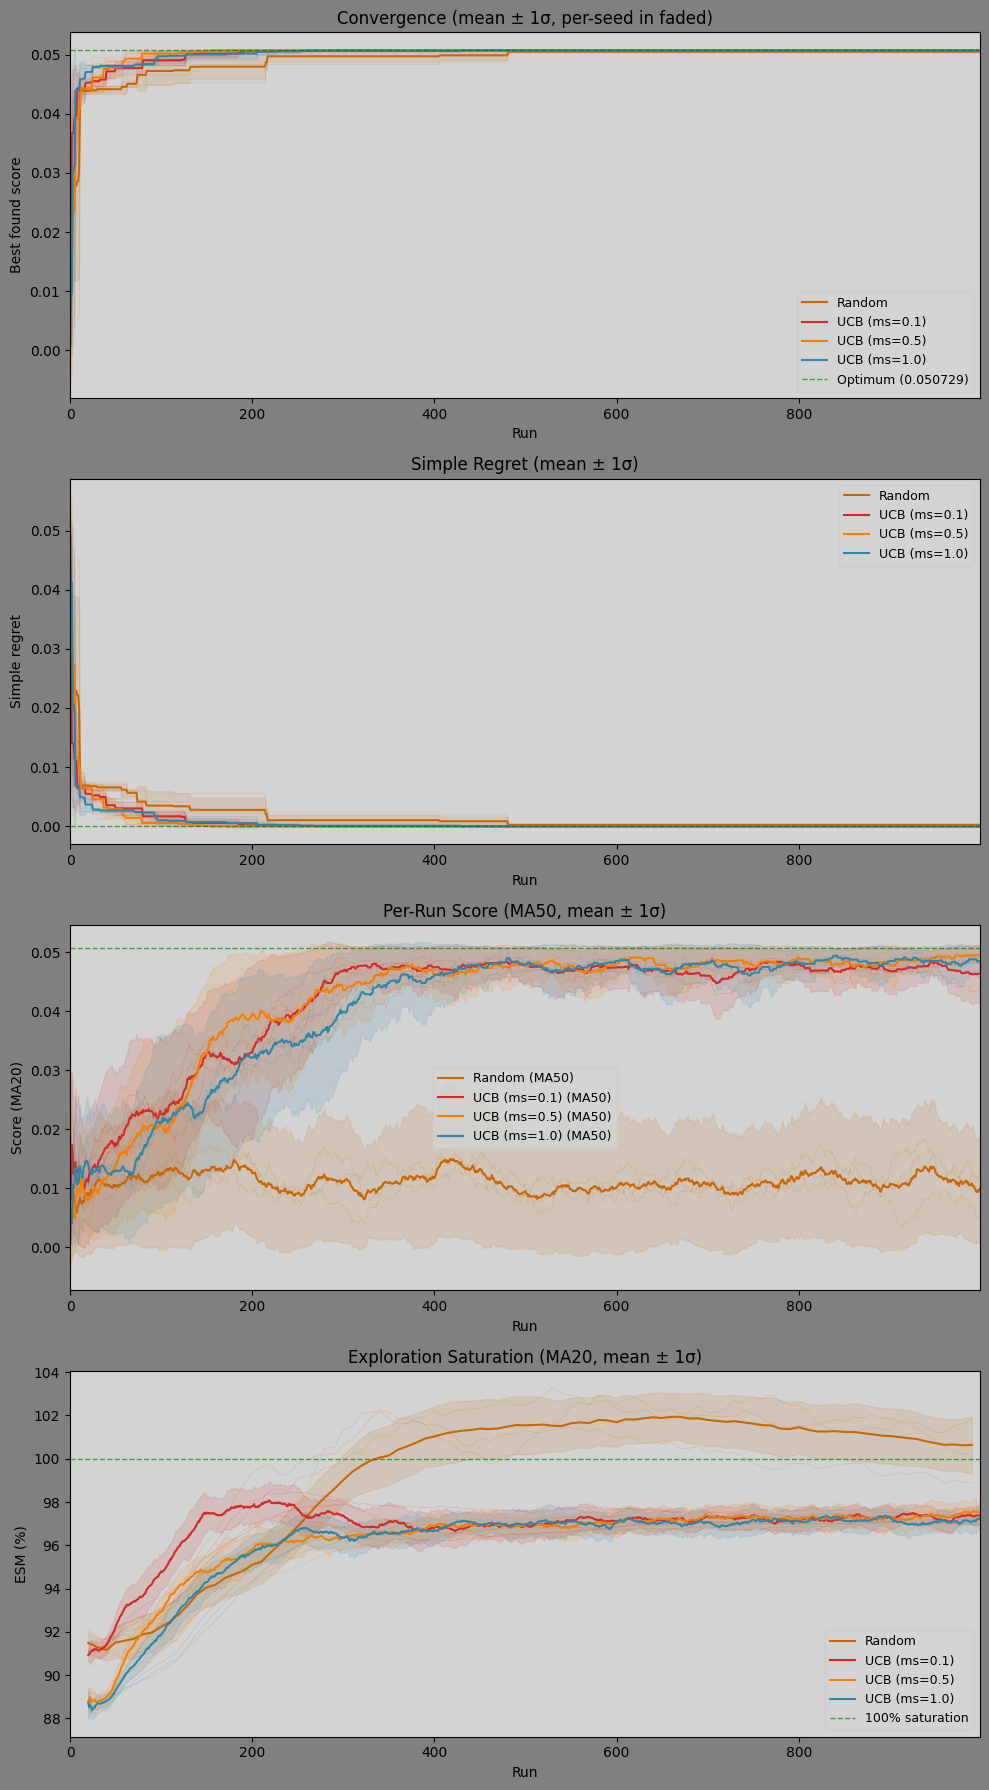

In [81]:
n_total = len(max_samples_experiment_results)
print(f"Total records : {n_total:,}")
print(f"Seeds        : {sorted(max_samples_experiment_results['seed'].unique().to_list())}")
print(f"Max samples  : {sorted(max_samples_experiment_results['max_samples'].unique().to_list())}")
print()

# Focus on the first N runs
focus_region_result = max_samples_experiment_results.filter(pl.col("run") <= 2000)

summary = (
    focus_region_result
    .group_by(["strategy", "max_samples", "seed"])
    .agg([
        pl.col("run").max().alias("runs"),
        pl.col("simple_regret").last().alias("final_regret"),
        pl.col("best_found").last().alias("best"),
        pl.col("esm").drop_nulls().last().alias("esm"),
    ])
    .sort(["strategy", "max_samples", "seed"])
)
print(summary)

plot_experiment(focus_region_result, CONFIGS, best_score)

### Last Mile Convergence Analysis
esm from the last 500 runs, showing what values of esm are reached in the final phase of the experiment.

In [96]:
max_samples_experiment_results.filter(
    pl.col("strategy") == "ucb",
    pl.col("run") >= pl.col("run").max() - 200,
    pl.col("run") < pl.col("run").max() - 0
).group_by(["strategy", "max_samples"]).agg(
    pl.col("run").min().alias("min_run"),
    pl.col("run").max().alias("max_run"),
    pl.col("esm").mean().alias("esm_mean"),
    pl.col("esm").std().alias("esm_std")
).sort("max_samples")

strategy,max_samples,min_run,max_run,esm_mean,esm_std
str,f64,i64,i64,f64,f64
"""ucb""",0.1,799,998,97.297535,0.660269
"""ucb""",0.5,799,998,97.338195,0.745658
"""ucb""",1.0,799,998,97.144296,0.69528


### First Convergence Analysis (MA20)

Smooths ESM with a 20-run moving average per trajectory to assess saturation stability across different `max_samples` values.

In [97]:
max_samples_experiment_results.filter(
    pl.col("strategy") == "ucb",
).with_columns(
    pl.col("esm")
    .rolling_mean(window_size=20, min_samples=1)
    .over(["strategy", "max_samples", "seed"])
    .alias("esm_ma20")
).group_by(["strategy", "max_samples", "seed"]).agg(
    esm95_count = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 95).count(),
    esm95_ratio = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 95).count() / pl.col("esm_ma20").count(),
    esm95_first = pl.col("run").filter(pl.col("esm_ma20") >= 95).min().alias("first_esm_95"),
    esm99_count = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 99).count(),
    esm99_ratio = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 99).count() / pl.col("esm_ma20").count(),
    esm99_first = pl.col("run").filter(pl.col("esm_ma20") >= 99).min().alias("first_esm_99"),
    esm100_count = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 100).count(),
    esm100_ratio = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 100).count() / pl.col("esm_ma20").count(),
    esm100_first = pl.col("run").filter(pl.col("esm_ma20") >= 100).min().alias("first_esm_100"),
).group_by(["strategy", "max_samples"]).agg(
    esm95_count = pl.col("esm95_count").mean(),
    esm95_ratio = pl.col("esm95_ratio").mean(),
    esm95_first = pl.col("esm95_first").mean(),
    esm99_count = pl.col("esm99_count").mean(),
    esm99_ratio = pl.col("esm99_ratio").mean(),
    esm99_first = pl.col("esm99_first").mean(),
    esm100_count = pl.col("esm100_count").mean(),
    esm100_ratio = pl.col("esm100_ratio").mean(),
    esm100_first = pl.col("esm100_first").mean(),
).sort("max_samples")

strategy,max_samples,esm95_count,esm95_ratio,esm95_first,esm99_count,esm99_ratio,esm99_first,esm100_count,esm100_ratio,esm100_first
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ucb""",0.1,893.666667,0.911905,106.333333,0.0,0.0,null,0.0,0.0,null
"""ucb""",0.5,837.666667,0.854762,162.333333,0.0,0.0,null,0.0,0.0,null
"""ucb""",1.0,822.666667,0.839456,172.666667,0.0,0.0,null,0.0,0.0,null


## Experiment 5 — n_estimators sweep

Comparing `n_estimators ∈ {128, 256, 512, 1024}` for UCB acquisition. All with `max_samples=0.1`, `virtual_lambda=1.0`, `min_samples_leaf=3`, β=1.0.

In [ ]:
CONFIGS = [
    {"strategy": "random", "estimator_count": 128, "max_samples": 0.1, "virtual_lambda": 1.0, "min_samples_leaf": 3, "beta": 1.0, "virtual_sample_count": 100, "label": "Random",                  "color": "#ca6702"},
    {"strategy": "ucb",    "estimator_count": 128, "max_samples": 0.1, "virtual_lambda": 1.0, "min_samples_leaf": 3, "beta": 1.0, "virtual_sample_count": 100, "label": "UCB (128 trees)",        "color": "#d62828"},
    {"strategy": "ucb",    "estimator_count": 256, "max_samples": 0.1, "virtual_lambda": 1.0, "min_samples_leaf": 3, "beta": 1.0, "virtual_sample_count": 100, "label": "UCB (256 trees)",        "color": "#f77f00"},
    {"strategy": "ucb",    "estimator_count": 512, "max_samples": 0.1, "virtual_lambda": 1.0, "min_samples_leaf": 3, "beta": 1.0, "virtual_sample_count": 100, "label": "UCB (512 trees)",        "color": "#2e86ab"},
    {"strategy": "ucb",    "estimator_count": 1024,"max_samples": 0.1, "virtual_lambda": 1.0, "min_samples_leaf": 3, "beta": 1.0, "virtual_sample_count": 100, "label": "UCB (1024 trees)",       "color": "#2d6a4f"},
]
N_TRAJECTORIES = 3
N_RUNS = 1000

n_total_runs = len(CONFIGS) * N_TRAJECTORIES * N_RUNS
print(f"Configs: {len(CONFIGS)} \u00d7 {N_TRAJECTORIES} seeds \u00d7 {N_RUNS} runs = {n_total_runs:,} total")

estimator_experiment_results: pl.DataFrame = run_experiment(CONFIGS, n_runs=N_RUNS, n_trajectories=N_TRAJECTORIES)

Configs: 5 × 3 seeds × 1000 runs = 15,000 total


Total records : 15,000
Seeds        : [0, 1, 2]
Trees        : [128, 256, 512, 1024]

shape: (15, 7)
┌──────────┬─────────────────┬──────┬──────┬──────────────┬──────────┬──────────┐
│ strategy ┆ estimator_count ┆ seed ┆ runs ┆ final_regret ┆ best     ┆ esm      │
│ ---      ┆ ---             ┆ ---  ┆ ---  ┆ ---          ┆ ---      ┆ ---      │
│ str      ┆ i64             ┆ i64  ┆ i64  ┆ f64          ┆ f64      ┆ f64      │
╞══════════╪═════════════════╪══════╪══════╪══════════════╪══════════╪══════════╡
│ random   ┆ 128             ┆ 0    ┆ 999  ┆ 0.001525     ┆ 0.049204 ┆ 101.1682 │
│ random   ┆ 128             ┆ 1    ┆ 999  ┆ 0.000513     ┆ 0.050216 ┆ 99.3011  │
│ random   ┆ 128             ┆ 2    ┆ 999  ┆ 0.001211     ┆ 0.049518 ┆ 100.3092 │
│ ucb      ┆ 128             ┆ 0    ┆ 999  ┆ 0.0          ┆ 0.050729 ┆ 97.7168  │
│ ucb      ┆ 128             ┆ 1    ┆ 999  ┆ 0.0          ┆ 0.050729 ┆ 97.4746  │
│ ucb      ┆ 128             ┆ 2    ┆ 999  ┆ 0.0          ┆ 0.050729 ┆ 97.8882 

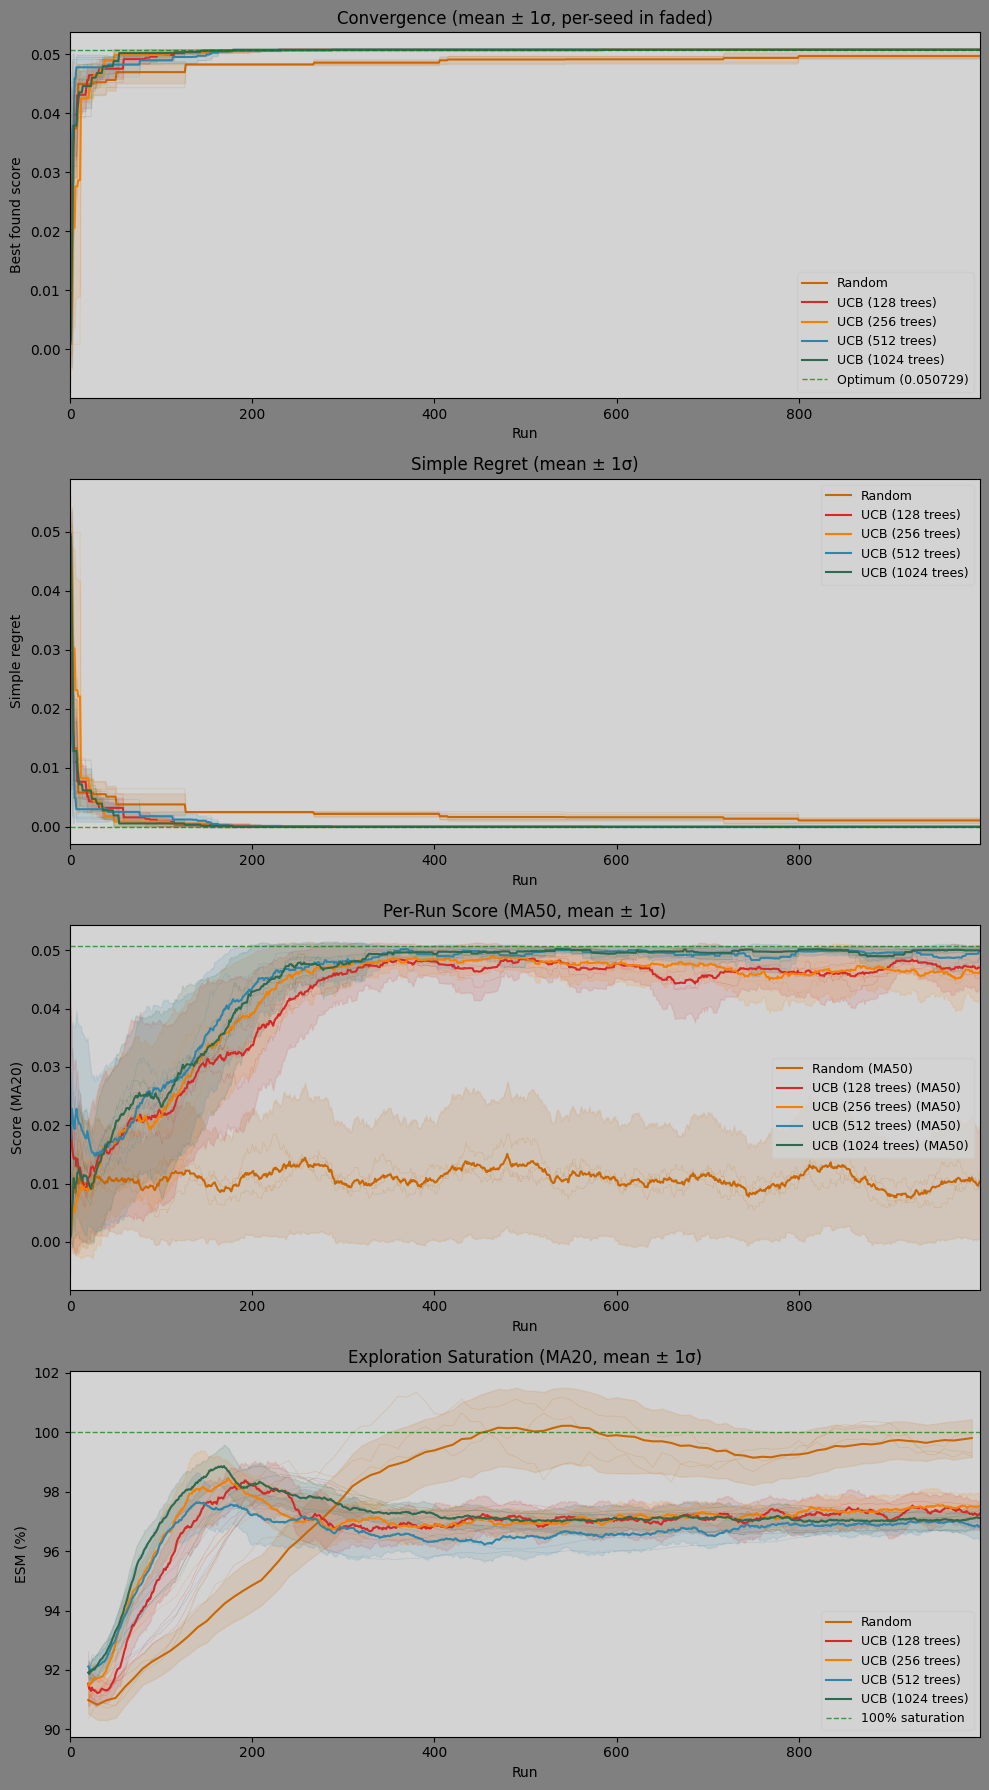

In [87]:
n_total = len(estimator_experiment_results)
print(f"Total records : {n_total:,}")
print(f"Seeds        : {sorted(estimator_experiment_results['seed'].unique().to_list())}")
print(f"Trees        : {sorted(estimator_experiment_results['estimator_count'].unique().to_list())}")
print()

# Focus on the first N runs
focus_region_result = estimator_experiment_results.filter(pl.col("run") <= 2000)

summary = (
    focus_region_result
    .group_by(["strategy", "estimator_count", "seed"])
    .agg([
        pl.col("run").max().alias("runs"),
        pl.col("simple_regret").last().alias("final_regret"),
        pl.col("best_found").last().alias("best"),
        pl.col("esm").drop_nulls().last().alias("esm"),
    ])
    .sort(["strategy", "estimator_count", "seed"])
)
print(summary)

plot_experiment(focus_region_result, CONFIGS, best_score, group_keys=("strategy", "estimator_count"))

### Last Mile Convergence Analysis
esm from the last 500 runs, showing what values of esm are reached in the final phase of the experiment.

In [89]:
estimator_experiment_results.filter(
    pl.col("strategy") == "ucb",
    pl.col("run") >= pl.col("run").max() - 200,
    pl.col("run") < pl.col("run").max() - 0
).group_by(["strategy", "estimator_count"]).agg(
    pl.col("run").min().alias("min_run"),
    pl.col("run").max().alias("max_run"),
    pl.col("esm").mean().alias("esm_mean"),
    pl.col("esm").std().alias("esm_std")
).sort("estimator_count")

strategy,estimator_count,min_run,max_run,esm_mean,esm_std
str,i64,i64,i64,f64,f64
"""ucb""",128,799,998,97.308106,0.716837
"""ucb""",256,799,998,97.429668,0.602551
"""ucb""",512,799,998,96.912396,0.471609
"""ucb""",1024,799,998,97.040768,0.440678


### First Convergence Analysis (MA20)

Smooths ESM with a 20-run moving average per trajectory to assess saturation stability across different tree counts.

In [90]:
estimator_experiment_results.filter(
    pl.col("strategy") == "ucb",
).with_columns(
    pl.col("esm")
    .rolling_mean(window_size=20, min_samples=1)
    .over(["strategy", "estimator_count", "seed"])
    .alias("esm_ma20")
).group_by(["strategy", "estimator_count", "seed"]).agg(
    esm95_count = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 95).count(),
    esm95_ratio = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 95).count() / pl.col("esm_ma20").count(),
    esm95_first = pl.col("run").filter(pl.col("esm_ma20") >= 95).min().alias("first_esm_95"),
    esm99_count = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 99).count(),
    esm99_ratio = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 99).count() / pl.col("esm_ma20").count(),
    esm99_first = pl.col("run").filter(pl.col("esm_ma20") >= 99).min().alias("first_esm_99"),
    esm100_count = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 100).count(),
    esm100_ratio = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 100).count() / pl.col("esm_ma20").count(),
    esm100_first = pl.col("run").filter(pl.col("esm_ma20") >= 100).min().alias("first_esm_100"),
).group_by(["strategy", "estimator_count"]).agg(
    esm95_count = pl.col("esm95_count").mean(),
    esm95_ratio = pl.col("esm95_ratio").mean(),
    esm95_first = pl.col("esm95_first").mean(),
    esm99_count = pl.col("esm99_count").mean(),
    esm99_ratio = pl.col("esm99_ratio").mean(),
    esm99_first = pl.col("esm99_first").mean(),
    esm100_count = pl.col("esm100_count").mean(),
    esm100_ratio = pl.col("esm100_ratio").mean(),
    esm100_first = pl.col("esm100_first").mean(),
).sort("estimator_count")

strategy,estimator_count,esm95_count,esm95_ratio,esm95_first,esm99_count,esm99_ratio,esm99_first,esm100_count,esm100_ratio,esm100_first
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ucb""",128,899.666667,0.918027,96.666667,0.666667,0.00068,216.0,0.0,0.0,null
"""ucb""",256,922.333333,0.941156,77.666667,8.666667,0.008844,132.0,0.0,0.0,null
"""ucb""",512,921.666667,0.940476,78.333333,0.0,0.0,null,0.0,0.0,null
"""ucb""",1024,930.666667,0.94966,69.333333,10.0,0.010204,152.0,0.0,0.0,null


## Experiment 6 — virtual_sample_count sweep

Comparing `virtual_sample_count ∈ {0, 25, 50, 100, 200, 400, 800}` for UCB acquisition. All with `max_samples=0.1`, `lambda=1.0`, `beta=1.0`, `leaf=3`, 128 trees.

In [ ]:
CONFIGS = [
    {"strategy": "random", "min_samples_leaf": 3, "max_samples": 0.1, "virtual_lambda": 1.0, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 100, "label": "Random",            "color": "#ca6702"},
    {"strategy": "ucb",    "min_samples_leaf": 3, "max_samples": 0.1, "virtual_lambda": 1.0, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 0,   "label": "UCB (K=0)",        "color": "#d62828"},
    {"strategy": "ucb",    "min_samples_leaf": 3, "max_samples": 0.1, "virtual_lambda": 1.0, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 25,  "label": "UCB (K=25)",       "color": "#f77f00"},
    {"strategy": "ucb",    "min_samples_leaf": 3, "max_samples": 0.1, "virtual_lambda": 1.0, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 50,  "label": "UCB (K=50)",       "color": "#2e86ab"},
    {"strategy": "ucb",    "min_samples_leaf": 3, "max_samples": 0.1, "virtual_lambda": 1.0, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 100, "label": "UCB (K=100)",      "color": "#2d6a4f"},
    {"strategy": "ucb",    "min_samples_leaf": 3, "max_samples": 0.1, "virtual_lambda": 1.0, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 200, "label": "UCB (K=200)",      "color": "#7209b7"},
    {"strategy": "ucb",    "min_samples_leaf": 3, "max_samples": 0.1, "virtual_lambda": 1.0, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 400, "label": "UCB (K=400)",      "color": "#e63946"},
    {"strategy": "ucb",    "min_samples_leaf": 3, "max_samples": 0.1, "virtual_lambda": 1.0, "beta": 1.0, "estimator_count": 128, "virtual_sample_count": 800, "label": "UCB (K=800)",      "color": "#457b9d"},
]
N_TRAJECTORIES = 3
N_RUNS = 2000

n_total_runs = len(CONFIGS) * N_TRAJECTORIES * N_RUNS
print(f"Configs: {len(CONFIGS)} x {N_TRAJECTORIES} seeds x {N_RUNS} runs = {n_total_runs:,} total")

k_experiment_results: pl.DataFrame = run_experiment(CONFIGS, n_runs=N_RUNS, n_trajectories=N_TRAJECTORIES)


[UCB (K=0)] 1560/2000  best=0.050729  regret=0.000000  ma20=0.049469
[UCB (K=0)] 1560/2000  best=0.050729  regret=0.000000  ma20=0.048976
[UCB (K=50)] 1560/2000  best=0.050729  regret=0.000000  ma20=0.049047
[UCB (K=400)]  820/2000  best=0.050729  regret=0.000000  ma20=0.048620
[UCB (K=50)] 1540/2000  best=0.050729  regret=0.000000  ma20=0.048816
[UCB (K=25)] 1560/2000  best=0.050729  regret=0.000000  ma20=0.049539
[UCB (K=100)] 1520/2000  best=0.050729  regret=0.000000  ma20=0.048377
[UCB (K=200)]  840/2000  best=0.050729  regret=0.000000  ma20=0.047591
[UCB (K=25)] 1560/2000  best=0.050729  regret=0.000000  ma20=0.049707
[UCB (K=200)]  840/2000  best=0.050729  regret=0.000000  ma20=0.043961
[UCB (K=100)] 1540/2000  best=0.050729  regret=0.000000  ma20=0.048487
[UCB (K=50)] 1560/2000  best=0.050729  regret=0.000000  ma20=0.047477
[UCB (K=200)] 1520/2000  best=0.050729  regret=0.000000  ma20=0.049060
[UCB (K=100)] 1540/2000  best=0.050729  regret=0.000000  ma20=0.045825
[UCB (K=0)] 158

Total records : 48,000
Seeds        : [0, 1, 2]
K values     : [0, 25, 50, 100, 200, 400, 800]

shape: (24, 7)
┌──────────┬──────────────────────┬──────┬──────┬──────────────┬──────────┬──────────┐
│ strategy ┆ virtual_sample_count ┆ seed ┆ runs ┆ final_regret ┆ best     ┆ esm      │
│ ---      ┆ ---                  ┆ ---  ┆ ---  ┆ ---          ┆ ---      ┆ ---      │
│ str      ┆ i64                  ┆ i64  ┆ i64  ┆ f64          ┆ f64      ┆ f64      │
╞══════════╪══════════════════════╪══════╪══════╪══════════════╪══════════╪══════════╡
│ random   ┆ 100                  ┆ 0    ┆ 1999 ┆ 0.000233     ┆ 0.050496 ┆ 99.8023  │
│ random   ┆ 100                  ┆ 1    ┆ 1999 ┆ 0.000233     ┆ 0.050496 ┆ 99.8348  │
│ random   ┆ 100                  ┆ 2    ┆ 1999 ┆ 0.0          ┆ 0.050729 ┆ 98.5654  │
│ ucb      ┆ 0                    ┆ 0    ┆ 1999 ┆ 0.0          ┆ 0.050729 ┆ 100.0773 │
│ ucb      ┆ 0                    ┆ 1    ┆ 1999 ┆ 0.0          ┆ 0.050729 ┆ 99.594   │
│ ucb      ┆ 0     

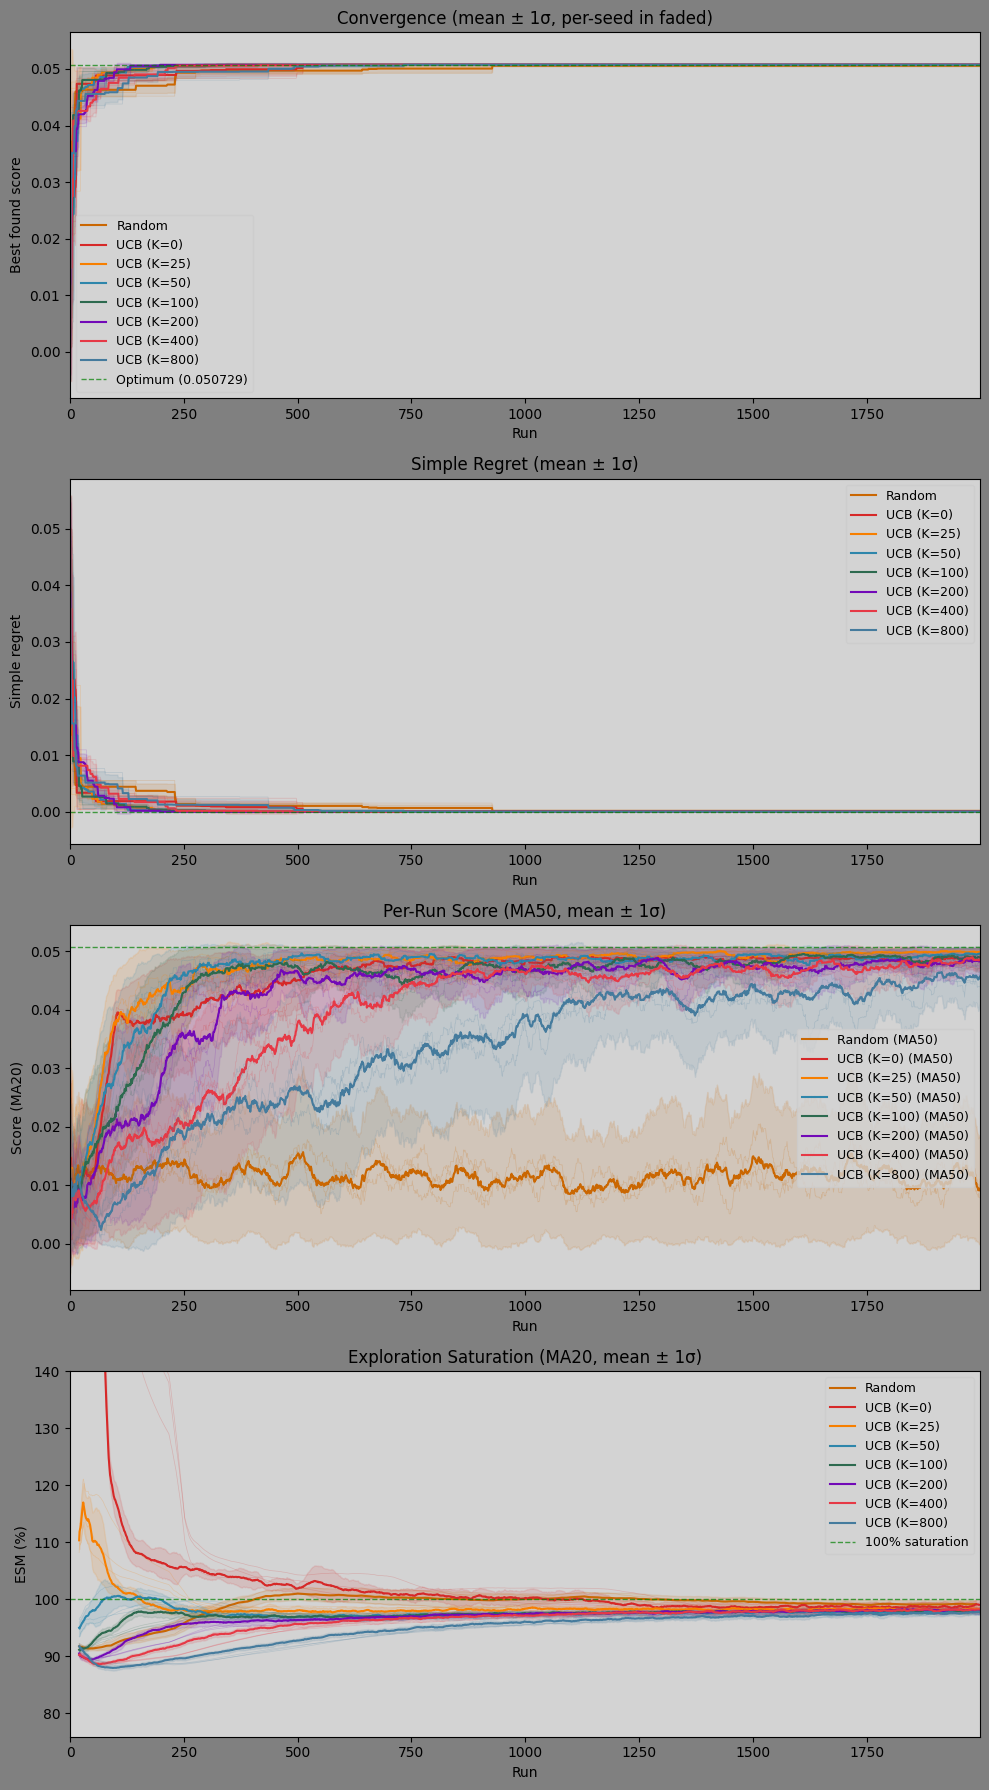

In [110]:
n_total = len(k_experiment_results)
print(f"Total records : {n_total:,}")
print(f"Seeds        : {sorted(k_experiment_results['seed'].unique().to_list())}")
print(f"K values     : {sorted(k_experiment_results['virtual_sample_count'].unique().to_list())}")
print()

focus_region_result = k_experiment_results.filter(pl.col("run") <= 2000)

summary = (
    focus_region_result
    .group_by(["strategy", "virtual_sample_count", "seed"])
    .agg([
        pl.col("run").max().alias("runs"),
        pl.col("simple_regret").last().alias("final_regret"),
        pl.col("best_found").last().alias("best"),
        pl.col("esm").drop_nulls().last().alias("esm"),
    ])
    .sort(["strategy", "virtual_sample_count", "seed"])
)
print(summary)

plot_experiment(focus_region_result, CONFIGS, best_score, group_keys=("strategy", "virtual_sample_count"))

### Last Mile Convergence Analysis

Analyzes raw ESM in the final 200 runs to assess terminal saturation stability.

In [111]:
k_experiment_results.filter(
    pl.col("strategy") == "ucb",
    pl.col("run") >= pl.col("run").max() - 200,
    pl.col("run") < pl.col("run").max() - 0
).group_by(["strategy", "virtual_sample_count"]).agg(
    pl.col("run").min().alias("min_run"),
    pl.col("run").max().alias("max_run"),
    pl.col("esm").mean().alias("esm_mean"),
    pl.col("esm").std().alias("esm_std")
).sort("virtual_sample_count")

strategy,virtual_sample_count,min_run,max_run,esm_mean,esm_std
str,i64,i64,i64,f64,f64
"""ucb""",0,1799,1998,98.719574,1.024321
"""ucb""",25,1799,1998,98.2161,0.678305
"""ucb""",50,1799,1998,97.817903,0.66953
"""ucb""",100,1799,1998,98.004182,0.671634
"""ucb""",200,1799,1998,98.136177,0.716713
"""ucb""",400,1799,1998,98.131825,0.695556
"""ucb""",800,1799,1998,97.59611,0.664123


### First Convergence Analysis (MA20)

Smooths ESM with a 20-run moving average per trajectory to assess saturation stability across different virtual sample counts.

In [112]:
k_experiment_results.filter(
    pl.col("strategy") == "ucb",
).with_columns(
    pl.col("esm")
    .rolling_mean(window_size=20, min_samples=1)
    .over(["strategy", "virtual_sample_count", "seed"])
    .alias("esm_ma20")
).group_by(["strategy", "virtual_sample_count", "seed"]).agg(
    esm95_count = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 95).count(),
    esm95_ratio = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 95).count() / pl.col("esm_ma20").count(),
    esm95_first = pl.col("run").filter(pl.col("esm_ma20") >= 95).min().alias("first_esm_95"),
    esm99_count = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 99).count(),
    esm99_ratio = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 99).count() / pl.col("esm_ma20").count(),
    esm99_first = pl.col("run").filter(pl.col("esm_ma20") >= 99).min().alias("first_esm_99"),
    esm100_count = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 100).count(),
    esm100_ratio = pl.col("esm_ma20").filter(pl.col("esm_ma20") >= 100).count() / pl.col("esm_ma20").count(),
    esm100_first = pl.col("run").filter(pl.col("esm_ma20") >= 100).min().alias("first_esm_100"),
).group_by(["strategy", "virtual_sample_count"]).agg(
    esm95_count = pl.col("esm95_count").mean(),
    esm95_ratio = pl.col("esm95_ratio").mean(),
    esm95_first = pl.col("esm95_first").mean(),
    esm99_count = pl.col("esm99_count").mean(),
    esm99_ratio = pl.col("esm99_ratio").mean(),
    esm99_first = pl.col("esm99_first").mean(),
    esm100_count = pl.col("esm100_count").mean(),
    esm100_ratio = pl.col("esm100_ratio").mean(),
    esm100_first = pl.col("esm100_first").mean(),
).sort("virtual_sample_count")

strategy,virtual_sample_count,esm95_count,esm95_ratio,esm95_first,esm99_count,esm99_ratio,esm99_first,esm100_count,esm100_ratio,esm100_first
str,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""ucb""",0,1980.0,1.0,20.0,1370.333333,0.692088,20.0,869.666667,0.439226,20.0
"""ucb""",25,1980.0,1.0,20.0,168.333333,0.085017,20.0,128.333333,0.064815,20.0
"""ucb""",50,1975.333333,0.997643,24.0,117.666667,0.059428,84.0,93.0,0.04697,93.333333
"""ucb""",100,1901.333333,0.960269,98.666667,0.0,0.0,null,0.0,0.0,null
"""ucb""",200,1792.0,0.905051,207.333333,0.0,0.0,null,0.0,0.0,null
"""ucb""",400,1571.0,0.793434,427.0,0.0,0.0,null,0.0,0.0,null
"""ucb""",800,1225.0,0.618687,759.666667,0.0,0.0,null,0.0,0.0,null
